In [1]:
import tensorflow as tf
import numpy as np

2025-07-18 21:10:33.430566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752873033.746987      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752873033.833606      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
row_length = 500
input_length = 4



In [4]:
X = np.random.rand(row_length, input_length)

In [26]:
y = np.eye(input_length)[X.argmax(axis=1)]
y

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(input_length, activation="softmax")
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(optimizer="adam", loss="mse")

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1878 - val_loss: 0.1874
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1845 - val_loss: 0.1856
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1828 - val_loss: 0.1843
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1810 - val_loss: 0.1830
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1789 - val_loss: 0.1815
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1748 - val_loss: 0.1795
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1719 - val_loss: 0.1764
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1703 - val_loss: 0.1721
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1652 - val_loss: 0.1671
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1616 - val_loss: 0.1617
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1566 - val_loss: 0.1560
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

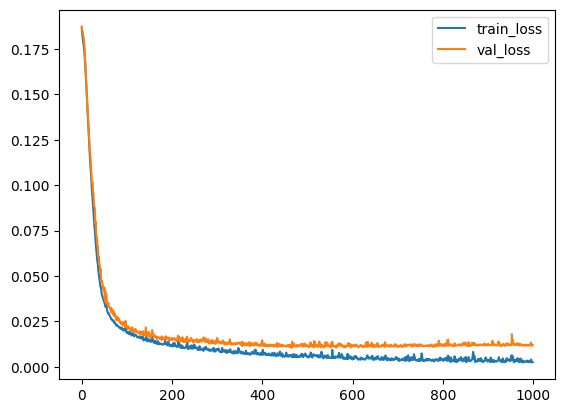

In [33]:
history = model.fit(X_train, y_train, epochs=1000, validation_data=(X_test, y_test))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


In [35]:
test = np.random.rand(5, 4)
test

array([[0.32642466, 0.72801105, 0.96778008, 0.04749043],
       [0.02144632, 0.7066052 , 0.7247565 , 0.48265489],
       [0.66266537, 0.79331962, 0.49063635, 0.86413825],
       [0.29428024, 0.03147347, 0.24543883, 0.2071324 ],
       [0.0206598 , 0.34583042, 0.28932645, 0.12293862]])

In [38]:
np.argmax(model.predict(test), axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([2, 2, 3, 0, 1])